# *ASSIGNMENT-1: Find the communities*

In [71]:
import networkx as nx
import pandas as pd
from pathlib import Path
import community as community_louvain
import time
import random
from itertools import combinations
import igraph as ig
import leidenalg
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
from collections import Counter

In [72]:
BASE_DIR = Path().resolve().parent
DATASET_PATH = BASE_DIR / "data" / "anime_filtered.csv"
df = pd.read_csv(DATASET_PATH)

In [73]:
def build_graph(filtered):
    G = nx.Graph()
    for _, row in filtered.iterrows():
        G.add_node(row["mal_id"], title=row["title"])
    for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
        genres_a = set(str(a["genres"]).split("|"))
        genres_b = set(str(b["genres"]).split("|"))
        if len(genres_a & genres_b) >= 2:
            G.add_edge(a["mal_id"], b["mal_id"])
    return G

In [74]:
G = build_graph(filtered=df)
print(G.number_of_nodes())
print(G.number_of_edges())

3579
780393


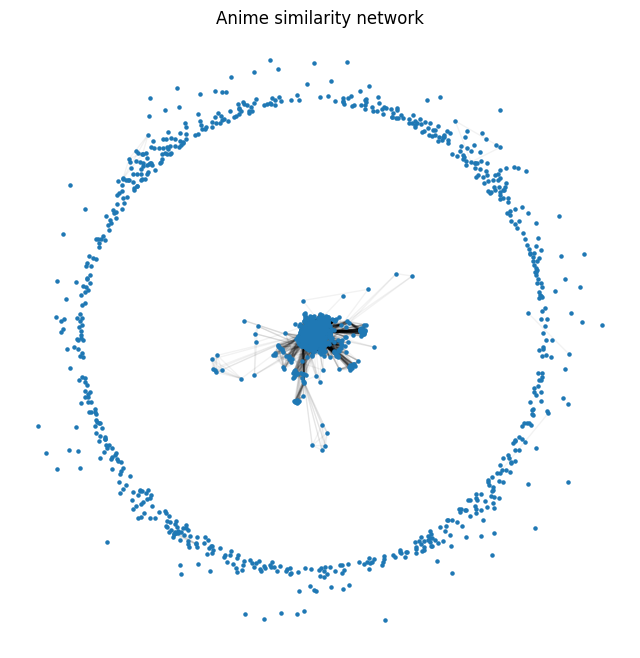

In [75]:
plt.figure(figsize=(8,8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=5)
nx.draw_networkx_edges(G, pos, alpha=0.05)
plt.title("Anime similarity network")
plt.axis("off")
plt.show()

## Community analysis

### Louvain algorithm

In [76]:
start = time.time()
partition_louvain = community_louvain.best_partition(G, random_state=42)
time_louvain = time.time() - start
num_louvain = len(set(partition_louvain.values()))
print("Louvain")
print("Communities:", num_louvain)
print(f"Execution time: {time_louvain:.3f} s")

Louvain
Communities: 733
Execution time: 7.480 s


In [77]:
louvain_sizes = Counter(partition_louvain.values())
community_sizes_louvain = pd.DataFrame(list(louvain_sizes.values()), columns=["Community Size"])
print("Louvain community sizes")
print("Top 10 community sizes:")
print(community_sizes_louvain.sort_values(by="Community Size", ascending=False).head(10))
print("Mean community size:", community_sizes_louvain["Community Size"].mean())
print("Maximum community size:",community_sizes_louvain["Community Size"].max())
print("Minimum community size:", community_sizes_louvain["Community Size"].min())


Louvain community sizes
Top 10 community sizes:
     Community Size
0              1002
1               865
3               671
5               272
281              21
297               8
26                7
300               4
51                3
392               2
Mean community size: 4.882673942701228
Maximum community size: 1002
Minimum community size: 1


### Leiden algorithm

In [78]:
ig.set_random_number_generator(random.Random(42))
g = ig.Graph.from_networkx(G)
start = time.time()
partition = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition)
time_leiden = time.time() - start
partition_leiden = {}

for community_id, members in enumerate(partition):
    for node in members:
        partition_leiden[g.vs[node]["_nx_name"]] = community_id

print(f"Leiden")
print(f"Communities: {len(partition)}")
print(f"Execution time: {time_leiden:.3f} s")

Leiden
Communities: 734
Execution time: 0.546 s


In [79]:
leiden_sizes = Counter(partition_leiden.values())
community_sizes_leiden = pd.DataFrame(list(leiden_sizes.values()), columns=["Community Size"])
print("Leiden community sizes")
print("Top 10 community sizes:")
print(community_sizes_leiden.sort_values(by="Community Size", ascending=False).head(10))
print("Mean community size:", community_sizes_leiden["Community Size"].mean())
print("Maximum community size:", community_sizes_leiden["Community Size"].max())
print("Minimum community size:", community_sizes_leiden["Community Size"].min())

Leiden community sizes
Top 10 community sizes:
   Community Size
0             999
1             949
2             663
3             191
4              20
5               9
6               8
7               7
8               4
9               3
Mean community size: 4.876021798365122
Maximum community size: 999
Minimum community size: 1


### Girvan-Newman algorithm

#### Poiché il grafo è molto grande, viene utilizzato un sottografo.

In [80]:
random.seed(42)
sub_nodes = random.sample(list(G.nodes()), 200)
G_small = G.subgraph(sub_nodes).copy()

In [81]:
start = time.time()
gn_generator = girvan_newman(G_small)
best_communities = None
best_modularity = -1

for communities in gn_generator:
    Q = modularity(G_small, communities)
    if Q > best_modularity:
        best_modularity = Q
        best_communities = communities

time_gn = time.time() - start
partition_gn = {}
for i, community in enumerate(best_communities):
    for node in community:
        partition_gn[node] = i

print("Girvan-Newman")
print(f"Communities: {len(best_communities)}")
print(f"Modularity: {best_modularity:.4f}")
print(f"Execution time: {time_gn:.3f} s")

Girvan-Newman
Communities: 52
Modularity: 0.3391
Execution time: 74.708 s


In [82]:
gn_sizes = Counter(partition_gn.values())
community_sizes_gn = pd.DataFrame(list(gn_sizes.values()), columns=["Community Size"])
print("Girvan-Newman community sizes")
print("Top 10 community sizes:")
print(community_sizes_gn.sort_values(by="Community Size", ascending=False).head(10))
print("Mean community size:", community_sizes_gn["Community Size"].mean())
print("Maximum community size:", community_sizes_gn["Community Size"].max())
print("Minimum community size:", community_sizes_gn["Community Size"].min())

Girvan-Newman community sizes
Top 10 community sizes:
    Community Size
2               82
4               30
6               29
1                7
10               3
0                2
15               2
3                1
7                1
8                1
Mean community size: 3.8461538461538463
Maximum community size: 82
Minimum community size: 1


### Summary

In [83]:
results = pd.DataFrame({
    "Algorithm": [
        "Louvain",
        "Leiden",
        "Girvan-Newman"
    ],
    "Communities": [
        len(set(partition_louvain.values())),
        len(set(partition_leiden.values())),
        len(set(partition_gn.values()))
    ],
    "Execution Time (s)": [
        round(time_louvain,3),
        round(time_leiden,3),
        round(time_gn,3)
    ]
})

results

,Algorithm,Communities,Execution Time (s)
0,Louvain,733,7.480
1,Leiden,734,0.546
2,Girvan-Newman,52,74.708


## Evaluate the quality of the communities

In [84]:
nodes = list(G.nodes())

labels_louvain = [partition_louvain[n] for n in nodes]
labels_leiden = [partition_leiden[n] for n in nodes]

In [85]:
nmi = normalized_mutual_info_score(labels_louvain, labels_leiden)
ari = adjusted_rand_score(labels_louvain, labels_leiden)

print("NMI:", nmi)
print("ARI:", ari)

NMI: 0.9391854507920854
ARI: 0.8750633333687118


#### Girvan-Newman was applied only to a reduced graph because of its computational complexity. Therefore, NMI and ARI were computed only between the Louvain and Leiden partitions obtained on the full graph.

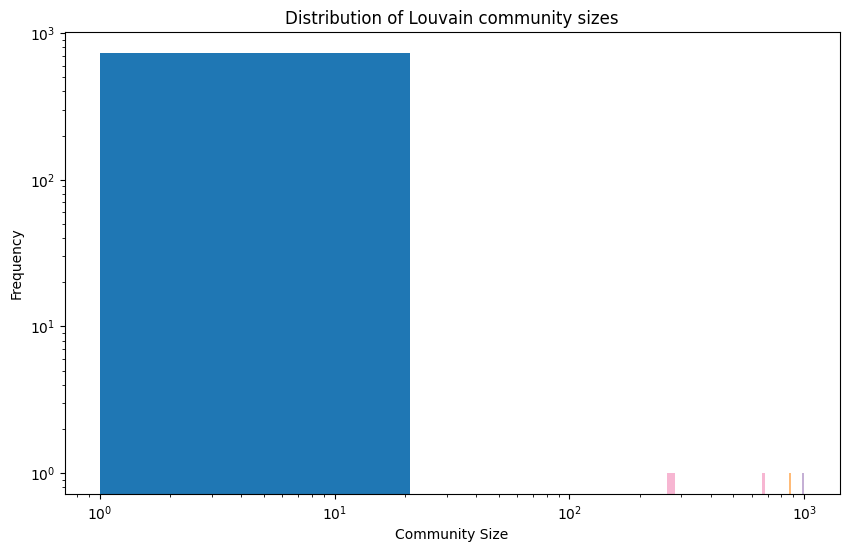

In [86]:
plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(community_sizes_louvain["Community Size"], bins=50)

for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.tab20(i % 20))

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Community Size")
plt.ylabel("Frequency")
plt.title("Distribution of Louvain community sizes")

plt.show()

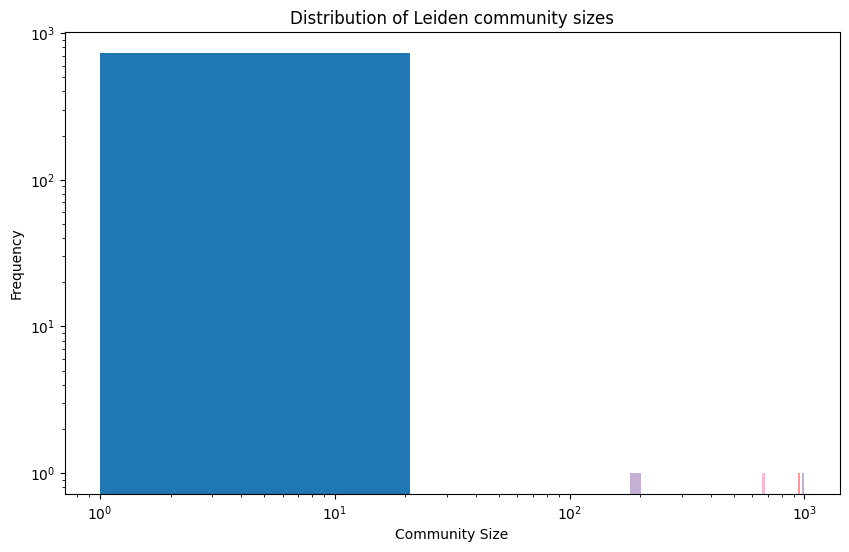

In [87]:
plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(community_sizes_leiden["Community Size"], bins=50)

for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.tab20(i % 20))

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Community Size")
plt.ylabel("Frequency")
plt.title("Distribution of Leiden community sizes")

plt.show()

### Draw the graph with different colors for the communities

In [88]:
def plot_communities(G, pos, partition, title, node_size=15):
    sizes = Counter(partition.values())
    communities = sorted(set(partition.values()))
    community_map = {community_id: i for i, community_id in enumerate(communities)}
    colors = [community_map[partition[node]] for node in G.nodes()]

    plt.figure(figsize=(10, 10))
    nx.draw_networkx_edges(G, pos, alpha=0.02, width=0.2)
    cmap = plt.colormaps["nipy_spectral"].resampled(len(communities))
    nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=cmap, node_size=node_size, vmin=0, vmax=len(communities)-1)

    plt.title(title)
    plt.axis("off")
    plt.show()

    print(f"Number of communities: {len(communities)}")
    print(f"Maximum community size: {max(sizes.values())}")
    print(f"Minimum community size: {min(sizes.values())}")

In [89]:
def plot_main_communities(G, pos, partition, title, min_size=20, node_size=15):
    sizes = Counter(partition.values())
    large_communities = {community_id for community_id, size in sizes.items() if size >= min_size}
    large_nodes = [node for node in G.nodes() if partition[node] in large_communities]
    small_nodes = [node for node in G.nodes() if partition[node] not in large_communities]
    community_map = {community_id: i for i, community_id in enumerate(sorted(large_communities))}
    colors = [community_map[partition[node]] for node in large_nodes]

    plt.figure(figsize=(10, 10))
    nx.draw_networkx_edges(G, pos, alpha=0.02, width=0.2)
    nx.draw_networkx_nodes(G, pos, nodelist=small_nodes, node_size=node_size, node_color="lightgray")
    nx.draw_networkx_nodes(G, pos, nodelist=large_nodes, node_size=node_size, node_color=colors, cmap=plt.colormaps["tab10"], vmin=0, vmax=len(large_communities)-1)

    plt.title(title)
    plt.axis("off")
    plt.show()

    print(f"Communities with at least {min_size} nodes: {len(large_communities)}")
    print(f"Small communities grouped together: {len(sizes) - len(large_communities)}")

### Louvain

Louvain communities:


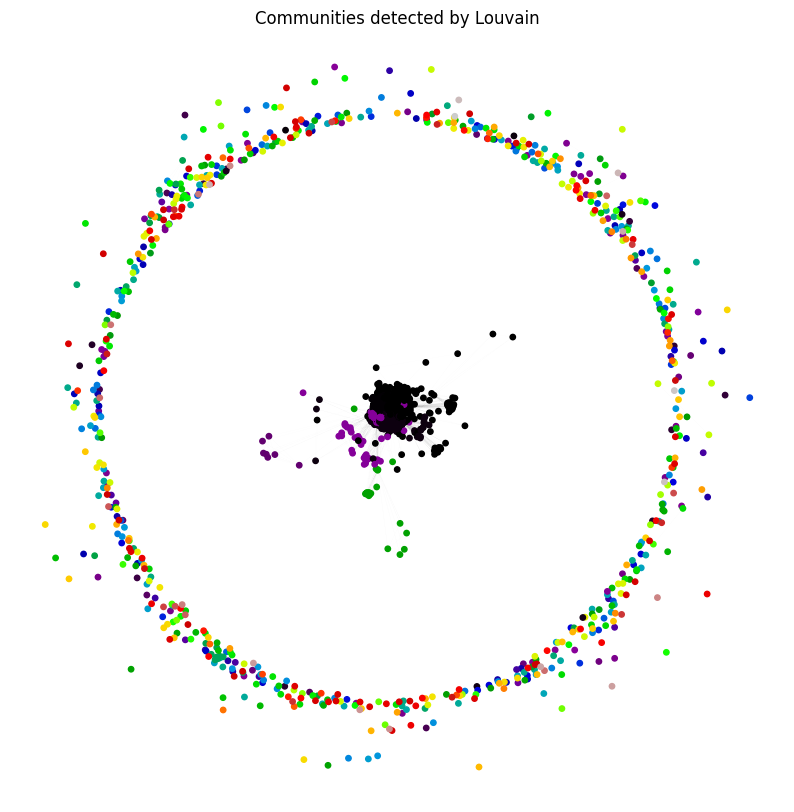

Number of communities: 733
Maximum community size: 1002
Minimum community size: 1


In [90]:
print("Louvain communities:")
plot_communities(G, pos, partition_louvain, "Communities detected by Louvain", node_size=15)

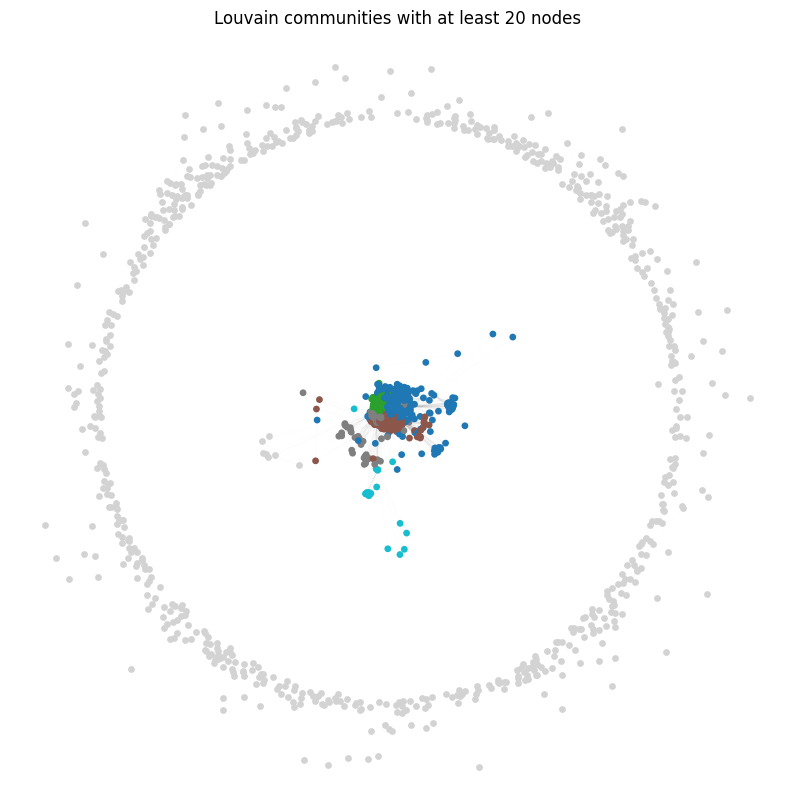

Communities with at least 20 nodes: 5
Small communities grouped together: 728


In [91]:
plot_main_communities(G, pos, partition_louvain, "Louvain communities with at least 20 nodes", min_size=20, node_size=15)

Leiden communities:


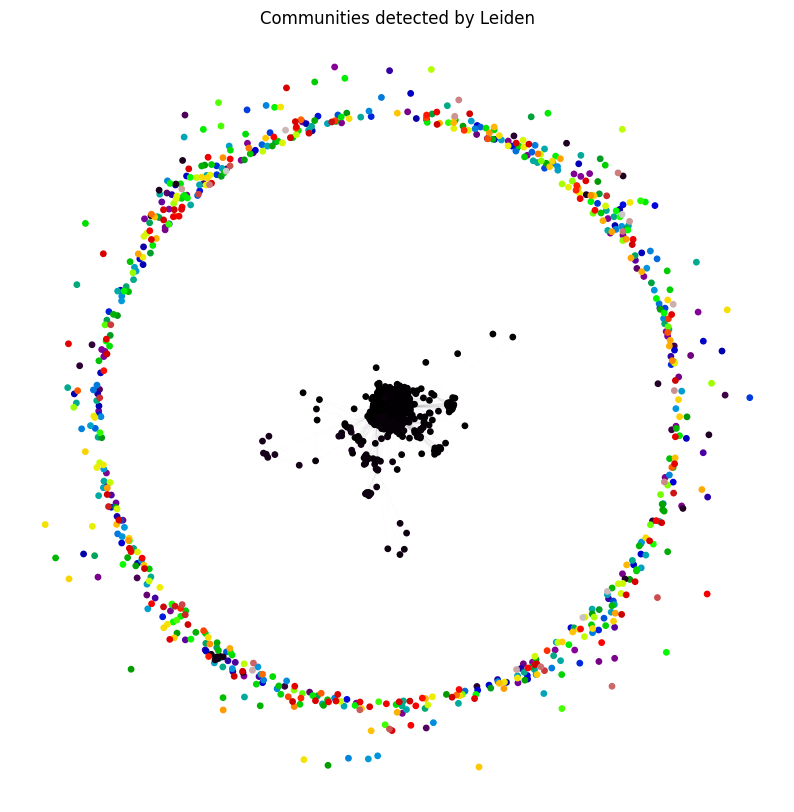

Number of communities: 734
Maximum community size: 999
Minimum community size: 1


In [92]:
print("Leiden communities:")
plot_communities(G, pos, partition_leiden, "Communities detected by Leiden", node_size=15)

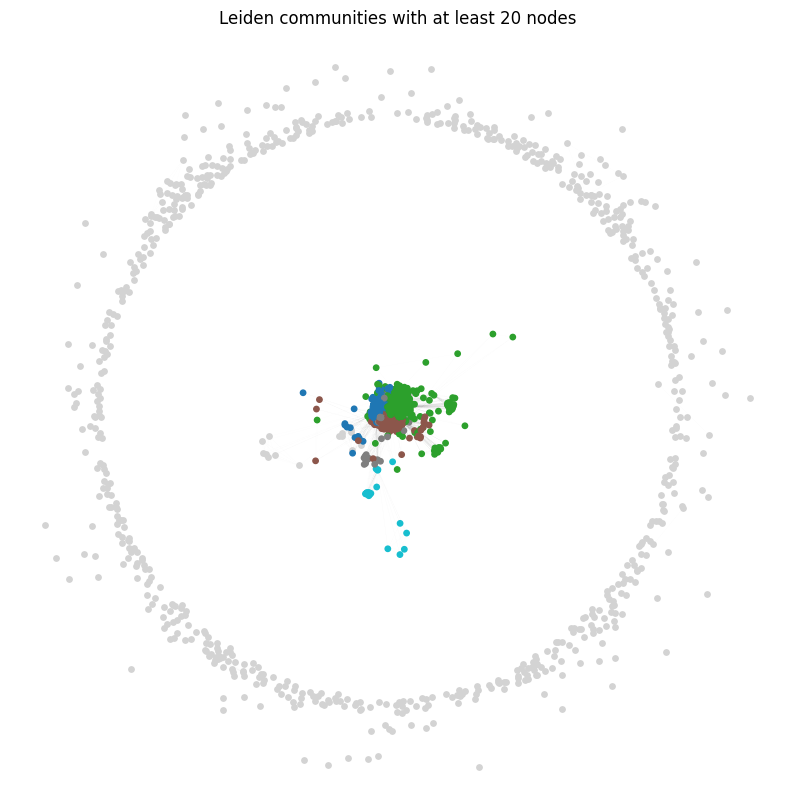

Communities with at least 20 nodes: 5
Small communities grouped together: 729


In [93]:
plot_main_communities(G, pos, partition_leiden, "Leiden communities with at least 20 nodes", min_size=20, node_size=15)

### Girvan-Newman

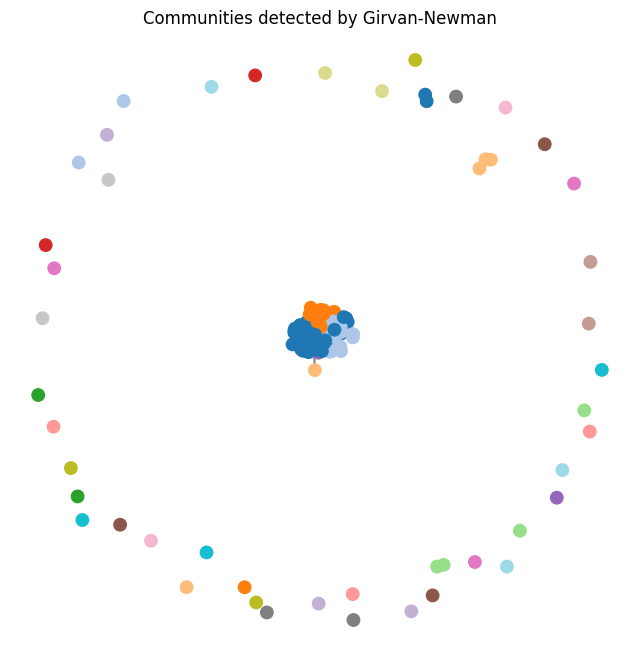

In [94]:
plt.figure(figsize=(8, 8))
pos_small = nx.spring_layout(G_small, seed=42)
colors = [partition_gn[n] for n in G_small.nodes()]
cmap_gn = plt.colormaps["tab20"].resampled(len(set(partition_gn.values())))
nx.draw_networkx_nodes(G_small, pos_small, node_color=colors, cmap=cmap_gn, node_size=80)
nx.draw_networkx_edges(G_small, pos_small, alpha=0.4)
plt.title("Communities detected by Girvan-Newman")
plt.axis("off")
plt.show()